In [1]:
import xarray as xr
import fsspec
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
import dask

import scipy

from pathlib import Path


# convert Kelvin to Celsius
def kelvin_to_celsius(tk):
    tc = tk - 273.15
    return tc
    
def calculate_relative_humidity_percent(t2_k, td_k):
    t2_c = kelvin_to_celsius(t2_k)
    td_c = kelvin_to_celsius(td_k)
    # saturated vapour pressure
    es = 6.11 * 10.0 ** (7.5 * t2_c / (237.3 + t2_c))
    # vapour pressure
    e = 6.11 * 10.0 ** (7.5 * td_c / (237.3 + td_c))
    rh = (e / es) * 100
    return rh

def calculate_saturation_vapour_pressure(t2_k):
    g = [
        -2.8365744e3,
        -6.028076559e3,
        1.954263612e1,
        -2.737830188e-2,
        1.6261698e-5,
        7.0229056e-10,
        -1.8680009e-13,
        2.7150305,
    ]
    ess = g[7] * np.log(t2_k)
    for i in range(7):
        ess = ess + g[i] * np.power(t2_k, (i - 2))
    ess = np.exp(ess) * 0.01  # hPa
    return ess

In [2]:
# Location coordinates
locations = {
    'cpt': (-33.8, 18.6),
    'jhb': (-26.1, 28.0),
    'abj': (5.45, -3.9),
    'lua': (-8.994111, 13.439933)
}

names = {'cpt': 'Cape Town', 'jhb': 'Johannesburg', 'abj': 'Abidjan', 'lua': 'Luanda'}

In [3]:
from dask.distributed import Client
client = Client()  
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 5
Total threads: 10,Total memory: 16.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:57204,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:57217,Total threads: 2
Dashboard: http://127.0.0.1:57219/status,Memory: 3.20 GiB
Nanny: tcp://127.0.0.1:57207,


In [4]:
variables = [ 'UTCI', 'tas', 'MRT', 'wvp', 'ws']
path = '../create_analysis_dataset/data/'
path = 'data/'
heat_index = 'UTCI'  

baseline_period = slice('1970', '1999')
recent_period = slice('1993', '2022')

In [5]:
ds = xr.open_zarr(f'{path}/heat_analysis_set.zarr')
ds = ds.sel(latitude = slice(20,-60))
ds['rh'] = calculate_relative_humidity_percent(ds.tas, ds.tasdp)
ds['wvp'] = (calculate_saturation_vapour_pressure(ds.tas) * ds.rh / 100.0) / 10.0  # water vapour pressure in kPa

ds = ds[variables]

ds = ds.chunk({'time': 1000, 'latitude':30, 'longitude':30})

In [6]:
heat_index_baseline = ds.sel(time=baseline_period)

In [7]:
heat_index_recent = ds.sel(time=recent_period)

In [8]:
baseline_threshold = heat_index_baseline['UTCI'].chunk({'time': -1}).quantile(0.99, dim='time', skipna=True).compute() 
baseline_masked = heat_index_baseline.where(heat_index_baseline['UTCI'] > baseline_threshold) 
baseline_means = baseline_masked.mean(dim='time', skipna=True).compute()

#threshold = heat_index_recent['UTCI'].chunk({'time': -1}).quantile(0.99, dim='time', skipna=True).compute() 
masked = heat_index_recent.where(heat_index_recent['UTCI'] > baseline_threshold) 
recent_means = masked.mean(dim='time', skipna=True).compute() 

/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


In [9]:
differences = {}
significance = {}
variables = [ 'UTCI', 'tas', 'MRT', 'wvp', 'ws']
for var in variables:
    diff = recent_means[var] - baseline_means[var]
    differences[var] = diff.compute()
    sign = diff.to_dataset(name = '_')
    sign['significance'] = (('latitude','longitude'),scipy.stats.ttest_ind(masked[var].resample(time='YE').mean(dim = 'time').values, 
                                                                           baseline_masked[var].resample(time='YE').mean(dim = 'time').values,
                                                                           nan_policy='omit')[1])
    sign = sign.significance
    significance[var] = (sign < 0.05).astype(int)

/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documen

In [10]:
# Define colormap and limits for each variable
cmaps = {
    'UTCI': cmocean.cm.balance,
    'tas': cmocean.cm.balance,
    'MRT': cmocean.cm.curl,
    'ws': cmocean.cm.delta,
    'wvp': cmocean.cm.tarn
}

vmin = {
    'UTCI': -4,
    'tas': -8,
    'MRT': -6,
    'ws': -2,
    'wvp': -4  # adjust if needed based on data
}

vmax = {
    'UTCI': 4,
    'tas': 8,
    'MRT': 6,
    'ws': 2,
    'wvp': 4  # adjust if needed
}

units = {
    'UTCI': '°C',
    'tas': '°C',
    'MRT': '°C',
    'ws': 'm/s',
    'wvp': 'hPa'
}

titles = {
    'UTCI': 'Universal Thermal Climate Index',
    'tas': 'Air Temperature',
    'MRT': 'Mean Radiant Temperature',
    'ws': 'Wind Speed',
    'wvp': 'Water Vapor Pressure'
}

variables = ['tas', 'MRT', 'wvp', 'ws']

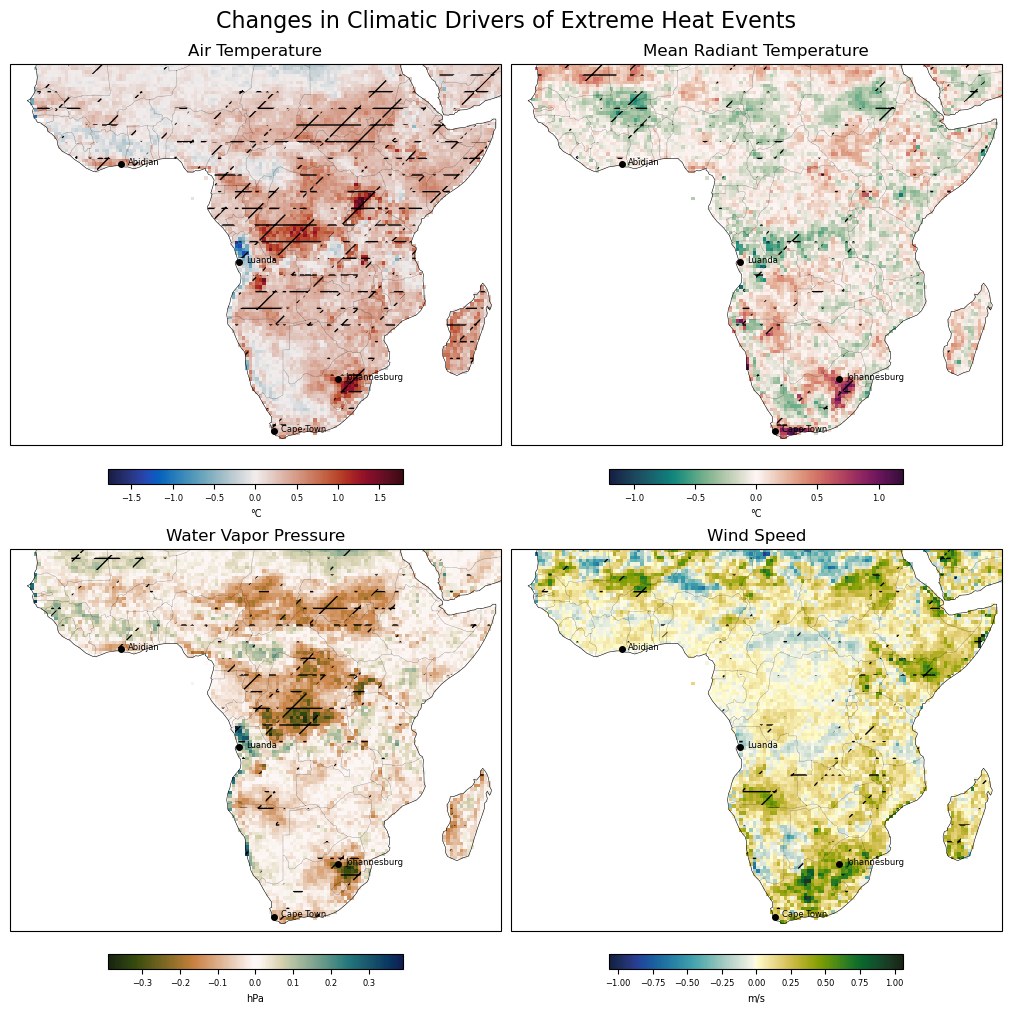

In [11]:
fig, axes = plt.subplots(
    nrows=2, ncols=2,
    figsize=(10, 10),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True
)

axes = axes.flatten()

# Plot each variable
for idx, var in enumerate(variables):
    ax = axes[idx]
    im = differences[var].plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmaps[var], 
        #vmin=vmin[var],
        #vmax=vmax[var],
        add_colorbar=False,
        add_labels=False
    )

    significance[var].plot.contourf(
        ax=ax,
        transform=ccrs.PlateCarree(),
        levels=[-0.5, 0.5, 1.5],
        hatches=[None, "-/"],
        colors="none",
        add_colorbar=False,
        alpha=0
        )
    
    ax.set_title(f'{titles[var]}', fontsize=12)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
    
    # Add colorbar
    cbar = fig.colorbar(im, ax=ax, orientation='horizontal', shrink=0.6, pad=0.05)
    cbar.ax.tick_params(labelsize=6)
    cbar.set_label(units[var], fontsize=7)

    # Add location markers
    for key, (lat, lon) in locations.items():
        ax.plot(lon, lat, marker='o', color='black', markersize=4, transform=ccrs.PlateCarree())
        ax.text(lon + 1, lat, names[key], fontsize=6, color='black', transform=ccrs.PlateCarree())


fig.suptitle('Changes in Climatic Drivers of Extreme Heat Events', fontsize=16)

plt.savefig('plots/03_exceedence_drivers.png', dpi=300)
plt.show()